## Face Recognition — PCA

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pca import PCA

data = np.load('face_data.npz')
X_train, X_test = data['X_train'], data['X_test']
y_train, y_test = data['y_train'], data['y_test']

### Fit PCA on Training Data (runs once, saves eigenvalues)

In [ ]:
pca = PCA()
pca.fit(X_train)  # computes and saves eigenvalues.npy & eigenvectors.npy

Eigenvalues saved.


### Load from saved files (skip fit next time)

In [3]:
pca = PCA()
pca.load()
pca.mean = X_train.mean(axis=0)  # mean still needed for projection

### Dimensionality for each variance threshold

In [4]:
alphas = [0.80, 0.85, 0.90, 0.95]

for alpha in alphas:
    k = pca.n_components_for_variance(alpha)
    print(f'α={alpha:.2f} → {k} components')

α=0.80 → 36 components
α=0.85 → 52 components
α=0.90 → 76 components
α=0.95 → 115 components


### Visualize Eigenfaces (top 10 principal components)

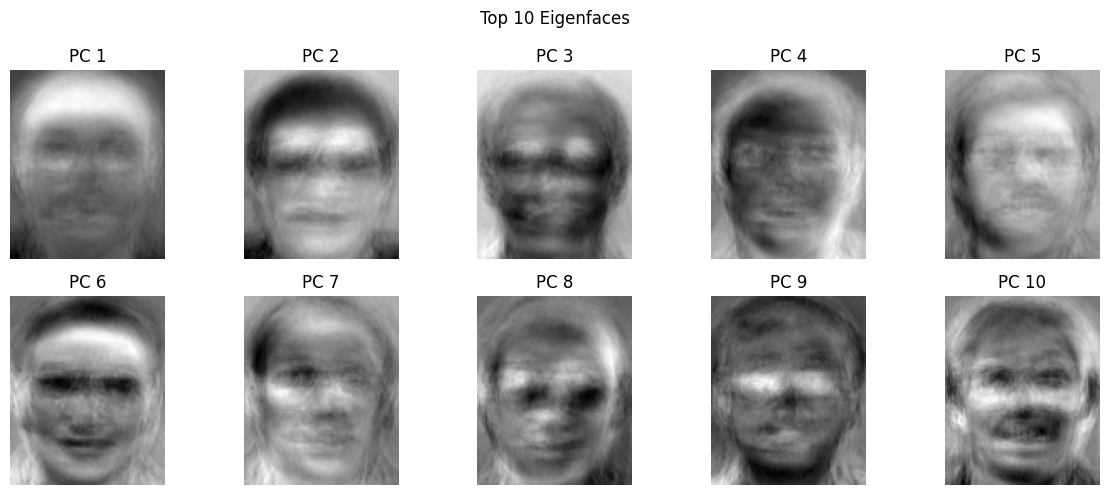

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    eigenface = pca.eigenvectors[i].reshape(112, 92)
    ax.imshow(eigenface, cmap='gray')
    ax.set_title(f'PC {i+1}')
    ax.axis('off')
plt.suptitle('Top 10 Eigenfaces')
plt.tight_layout()
plt.show()

### Visualize Sample Faces Reconstructed from PCA subspace

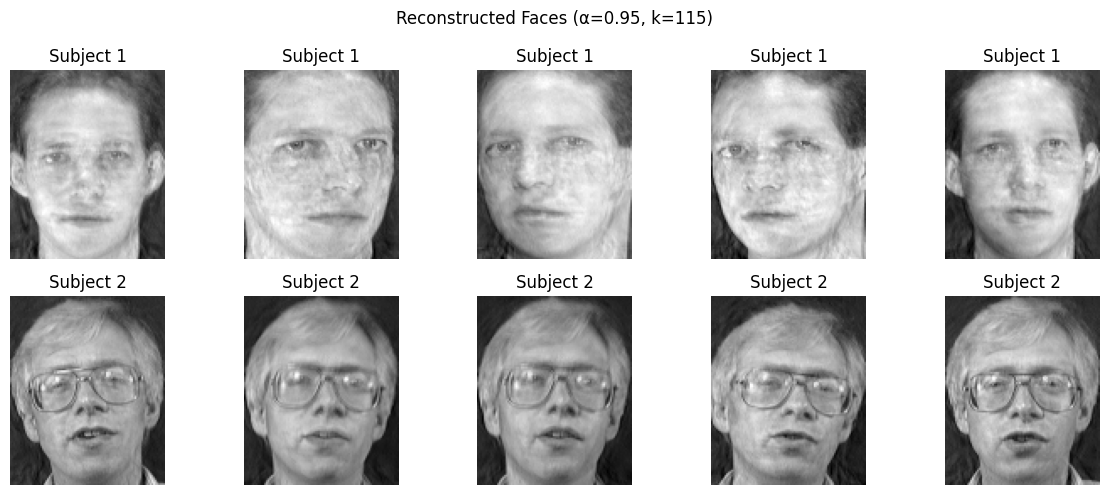

In [6]:
alpha = 0.95
k = pca.n_components_for_variance(alpha)
X_train_pca = pca.project(X_train, alpha)  # (200, k)

# Reconstruct back to image space
X_reconstructed = X_train_pca @ pca.eigenvectors[:k] + pca.mean

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_reconstructed[i].reshape(112, 92), cmap='gray')
    ax.set_title(f'Subject {y_train[i]}')
    ax.axis('off')
plt.suptitle(f'Reconstructed Faces (α={alpha}, k={k})')
plt.tight_layout()
plt.show()

### Project Train & Test sets for all thresholds

In [7]:
projected = {}
for alpha in alphas:
    k = pca.n_components_for_variance(alpha)
    projected[alpha] = {
        'X_train': pca.project(X_train, alpha),
        'X_test' : pca.project(X_test,  alpha),
        'k'      : k
    }
    print(f'α={alpha} → X_train: {projected[alpha]["X_train"].shape}, X_test: {projected[alpha]["X_test"].shape}')

α=0.8 → X_train: (200, 36), X_test: (200, 36)
α=0.85 → X_train: (200, 52), X_test: (200, 52)
α=0.9 → X_train: (200, 76), X_test: (200, 76)
α=0.95 → X_train: (200, 115), X_test: (200, 115)
